In [1]:
from dlfs.layers import DenseLayer
from dlfs.activation import ReLU, Sigmoid
from dlfs.loss import MSE_Loss, BCE_Loss
from dlfs.base import Module, Loss, Layer, Activation
from dlfs.optimizers import Optimizer_Adam, Optimizer_AdamW

import numpy as np
import matplotlib.pyplot as plt

In [2]:
class SequentialWrapper(Module):

    def __init__(self, layers: list[Layer | Module | Activation] = None) -> None:
        if layers is None:
            self.layers = []
        else:
            self.layers = layers

    def forward(self, x, training=False):
        self.layers[0].forward(x, training)

        for idx, layer in enumerate(self.layers[1:], start=1):
            layer.forward(self.layers[idx - 1].output, training)

        # Output of the model is the output of the last layer
        self.output = self.layers[-1].output

    def backward(self, delta):
        self.layers[-1].backward(delta)
        
        for idx, layer in reversed(list(enumerate(self.layers[:-1]))):
            layer.backward(self.layers[idx + 1].dinputs)

        self.dinputs = self.layers[0].dinputs

In [3]:
class VAE_Loss(Loss):

    def __init__(self, recon_loss):
        self.recon_loss = recon_loss

    def calculate(self, y_pred, y_true, mu, logvar, kl_beta=1.0):
        #logvar = np.clip(logvar, -10, 10)

        recon_loss = self.recon_loss.calculate(y_pred, y_true)

        #kl_per_sample = -0.5 * np.sum(1 + logvar - mu**2 - np.exp(logvar), axis=1)
        kl_loss = -0.5* np.mean(np.sum(1 + logvar - mu**2 - np.exp(logvar), axis=1))

        total_loss = recon_loss + kl_beta * kl_loss
        return recon_loss, kl_beta * kl_loss, total_loss

    def backward(self, y_pred, y_true, mu, logvar, kl_beta=1.0):
        #logvar = np.clip(logvar, -10, 10)
        self.recon_loss.backward(y_pred, y_true)

        batch_size = mu.shape[0]
        dmu = mu
        dlogvar = -0.5 * (1 - np.exp(logvar))

        self.dmu = kl_beta * dmu #/ batch_size
        self.dlogvar = kl_beta * dlogvar # / batch_size

class VAE(Module):

    def __init__(self, encoder, decoder, mu, logvar, loss_function = None, optimizer = None):
        self.encoder = encoder
        self.decoder = decoder
        self.mu = mu
        self.logvar = logvar
        self.loss_function = loss_function
        self.optimizer = optimizer

    def _reparametrize(self, mu, logvar):
        self.std = np.exp(0.5 * logvar)
        #self.rep_logvar = logvar
        #self.std = np.log(1 + np.exp(logvar))
        self.eps = np.random.randn(*self.std.shape)  # random noise
        self.z = mu + self.eps * self.std

    def _reparametrize_backward(self, decoder_dinputs, grad_kl_mu, grad_kl_logvar):
        self.dmu = decoder_dinputs * 1 + grad_kl_mu
        self.dlogvar = decoder_dinputs * (0.5 * self.eps * self.std) + grad_kl_logvar
        #self.dlogvar = decoder_dinputs * (np.exp(self.rep_logvar) / (1 + np.exp(self.rep_logvar))) + grad_kl_logvar

    def forward(self, x, training=False):
        self.encoder.forward(x, training=training)
        self.mu.forward(self.encoder.output, training=training)
        self.logvar.forward(self.encoder.output, training=training)

        self._reparametrize(self.mu.output, self.logvar.output)

        self.decoder.forward(self.z, training=training)

        self.output = self.decoder.output

    def backward(self, y_true, kl_beta):

        self.loss_function.backward(self.output, y_true, self.mu.output, self.logvar.output, kl_beta)
        recon_grad, mu_grad, logvar_grad = self.loss_function.recon_loss.dinputs, self.loss_function.dmu, self.loss_function.dlogvar
        self.decoder.backward(recon_grad)
        self._reparametrize_backward(self.decoder.dinputs, mu_grad, logvar_grad)
        self.mu.backward(self.dmu)
        self.logvar.backward(self.dlogvar)
        total_enc_grad = self.mu.dinputs + self.logvar.dinputs
        self.encoder.backward(total_enc_grad)

    def train(self, X: np.ndarray, epochs: int = 1000, batch_size: int = None, print_every: int = None, kl_warmup_steps: int = 0) -> None:

        self.rec_loss = []
        self.kl_loss = []

        for i in range(epochs + 1):

            if kl_warmup_steps and kl_warmup_steps > 0:
                self.kl_beta = min(1.0, (i + 1) / float(kl_warmup_steps))
            else:
                self.kl_beta = 1.0

            #print(f'kl beta_ {self.kl_beta}')

            if batch_size is None:

                # Forward pass
                self.forward(X, training=True)

                # Backward pass
                self.backward(X, self.kl_beta)

                # Update parameters
                self.optimizer.pre_update_parameters()
                self.optimizer.update_parameters(self)
                self.optimizer.post_update_parameters()

                rec_l, kl_l, loss = self.loss_function.calculate(self.output, X, self.mu.output, self.logvar.output, self.kl_beta)
                self.rec_loss.append(rec_l)
                self.kl_loss.append(kl_l)

                if print_every is not None:
                    if not i % print_every:
                        print(f'===== EPOCH : {i} ===== LOSS : {loss:.5f} (recon: {rec_l} | kl: {kl_l})')

            else:

                batch_loss = 0

                for j in range(0, len(X), batch_size):

                    # Subset data into a batch
                    batch_X = X[j:j+batch_size, :]

                    # Forward pass
                    self.forward(batch_X)

                    rec, kl, loss = self.loss_function.calculate(self.output, batch_X, self.mu.output, self.logvar.output)
                    batch_loss += loss

                    # Backward pass
                    self.backward(batch_X, self.kl_beta)

                    # Update parameters
                    self.optimizer.pre_update_parameters()
                    self.optimizer.update_parameters(self)
                    self.optimizer.post_update_parameters()

                if print_every is not None:
                    if not i % print_every:
                        print(f'===== EPOCH : {i} ===== LOSS : {batch_loss/batch_size:.5f} =====')


In [4]:
import struct

def load_mnist_images(file_path):
    with open(file_path, 'rb') as f:
        # Read the header information
        magic_number, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        # Read the image data
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows, cols)
        return images
    
def load_mnist_labels(file_path):
    with open(file_path, 'rb') as f:
        # Read the header information
        magic_number, num_labels = struct.unpack(">II", f.read(8))
        # Read the label data
        labels = np.fromfile(f, dtype=np.uint8)
        return labels
    
def load_mnist(path_train_data, path_train_labels, path_test_data, path_test_labels):
    X_train = load_mnist_images(path_train_data)
    y_train = load_mnist_labels(path_train_labels)

    X_test = load_mnist_images(path_test_data)
    y_test = load_mnist_labels(path_test_labels)

    return X_train, y_train, X_test, y_test

def preprocess_whole_mnist(x):
    x = x.astype("float32") / 255
    return x

def select_specific_labels(x, y, labels: list, limit):
    label_indices = []
    for l in labels:
        label_index = np.where(y == l)[0][:limit]
        label_indices.append(label_index)
    all_indices = np.hstack(label_indices)
    all_indices = np.random.permutation(all_indices)
    x, y = x[all_indices], y[all_indices]
    return x, y

In [5]:
path_train_data = "data/mnist/train-images.idx3-ubyte"
path_train_labels = "data/mnist/train-labels.idx1-ubyte"

path_test_data = "data/mnist/t10k-images.idx3-ubyte"
path_test_labels = "data/mnist/t10k-labels.idx1-ubyte"

X_train, y_train, X_test, y_test = load_mnist(path_train_data, path_train_labels, path_test_data, path_test_labels)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)


In [6]:
# only fives and threes
X_train, _ = select_specific_labels(X_train, y_train, labels=[0, 3, 9], limit=250)
X_train = preprocess_whole_mnist(X_train)

X_train = X_train.reshape(-1, 28*28)
print(X_train.shape)

(750, 784)


In [7]:
input_dim = 784
hidden_dim = 128
latent_dim = 64

enc = SequentialWrapper(
    [DenseLayer(input_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, hidden_dim),
     ReLU()]
)

mu = SequentialWrapper(
    [DenseLayer(hidden_dim, latent_dim),  # Mean of z
     ReLU()]
)

logvar = SequentialWrapper(
    [DenseLayer(hidden_dim, latent_dim),  # logvar
     ReLU()]
)

dec = SequentialWrapper(
    [DenseLayer(latent_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, hidden_dim),
     ReLU(),
     DenseLayer(hidden_dim, input_dim),
     Sigmoid()
     ]
)

In [8]:
lr = 1e-3
epochs = 5000
batch_size = None

loss_fn = VAE_Loss(recon_loss=BCE_Loss())
optimizer = Optimizer_Adam(learning_rate=lr, clip_grad=False)

model = VAE(encoder=enc, 
            decoder=dec, 
            mu=mu, 
            logvar=logvar, 
            loss_function = loss_fn, 
            optimizer=optimizer)

model.train(X_train, epochs=epochs, batch_size=batch_size, print_every=250, kl_warmup_steps=2000)

===== EPOCH : 0 ===== LOSS : 777.11118 (recon: 777.1077490694778 | kl: 0.0034298043477743755)
===== EPOCH : 250 ===== LOSS : 140.11016 (recon: 130.48794210150447 | kl: 9.622216837348418)
===== EPOCH : 500 ===== LOSS : 129.62135 (recon: 115.64537888279798 | kl: 13.97597043221066)
===== EPOCH : 750 ===== LOSS : 128.63359 (recon: 111.66713916804257 | kl: 16.96645579671412)
===== EPOCH : 1000 ===== LOSS : 128.63220 (recon: 109.68240730760235 | kl: 18.949789126010337)
===== EPOCH : 1250 ===== LOSS : 130.05444 (recon: 109.55916782902288 | kl: 20.49526865891289)
===== EPOCH : 1500 ===== LOSS : 130.23137 (recon: 108.64558080796719 | kl: 21.585790968486688)
===== EPOCH : 1750 ===== LOSS : 130.76975 (recon: 108.31383174791942 | kl: 22.45591645652497)
===== EPOCH : 2000 ===== LOSS : 132.57902 (recon: 108.6395662453785 | kl: 23.93945253470116)
===== EPOCH : 2250 ===== LOSS : 130.56307 (recon: 106.06418010487853 | kl: 24.49888979312013)
===== EPOCH : 2500 ===== LOSS : 128.98316 (recon: 104.49020126

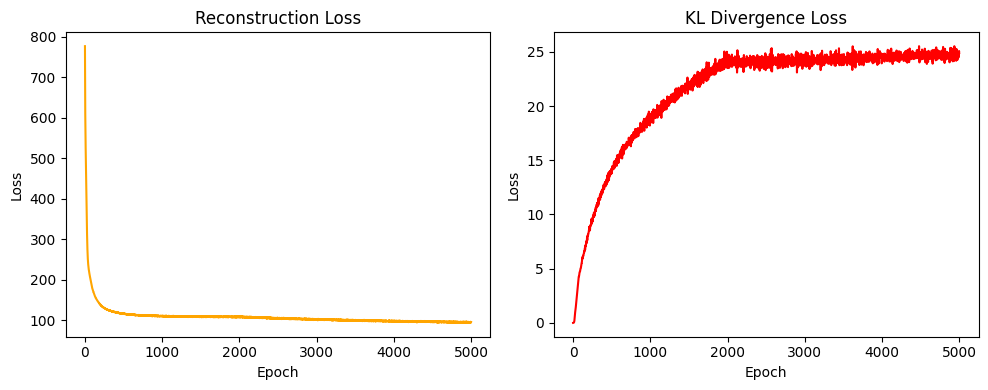

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(range(len(model.rec_loss)), model.rec_loss, color='orange')
axes[0].set_title("Reconstruction Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(range(len(model.kl_loss)), model.kl_loss, color='red')
axes[1].set_title("KL Divergence Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

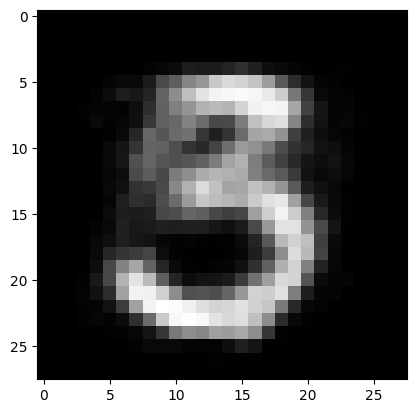

In [22]:
Z = np.random.randn(latent_dim)

model.decoder.forward(Z)
img = model.decoder.output.reshape(28, 28)

plt.imshow(img, cmap='gray')
plt.show()